/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 110ms/step - loss: 0.1088 - val_loss: 0.0311
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 0.0142 - val_loss: 0.0259
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0094 - val_loss: 0.0502
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 0.0116 - val_loss: 0.0232
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 0.0083 - val_loss: 0.0230
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0079 - val_loss: 0.0266
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0089 - val_loss: 0.0228
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0071 - val_loss: 0.0228
Epoch 9/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0075 - val_loss: 0.0228
Epoch 10/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 0.0077 - val_loss: 0.0227
Epoch 11/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0061 - val_loss: 0.0228
Epoch 12/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0065 - val_l

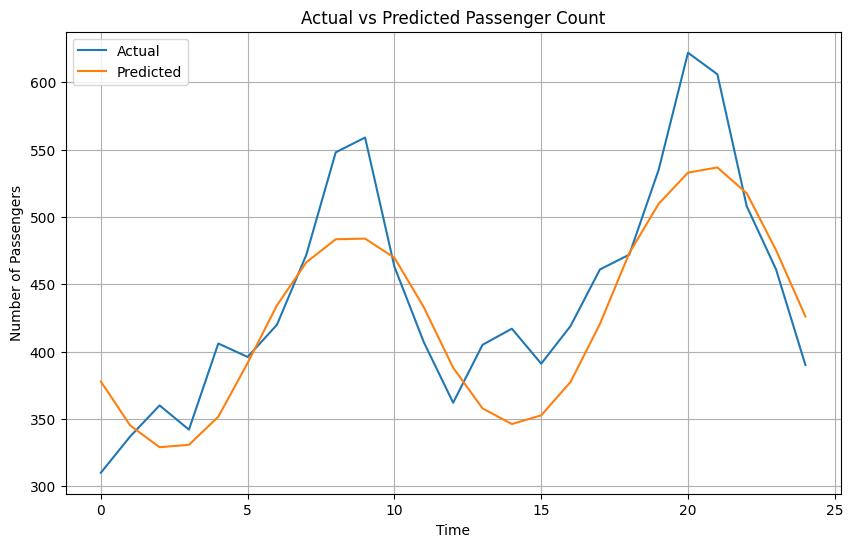

RMSE: 43.46, MAE: 35.14


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Load dataset
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv'
df = pd.read_csv(url, usecols=[1])
df.columns = ['Passengers']

# Normalize the dataset
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df)

# Create sequences
def create_dataset(data, time_step=20):
    X, Y = [], []
    for i in range(len(data) - time_step - 1):
        X.append(data[i:(i + time_step), 0])
        Y.append(data[i + time_step, 0])
    return np.array(X), np.array(Y)

time_step = 20
X, y = create_dataset(scaled_data, time_step)
X = X.reshape(X.shape[0], X.shape[1], 1)

# Split into train/test
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build model
model = Sequential()
model.add(LSTM(64, return_sequences=True, input_shape=(time_step, 1)))
model.add(LSTM(64))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=16, verbose=1)

# Prediction
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Invert scaling
train_predict_inv = scaler.inverse_transform(train_predict.reshape(-1, 1))
test_predict_inv = scaler.inverse_transform(test_predict.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))

# Plot prediction vs actual
plt.figure(figsize=(10, 6))
plt.plot(y_test_inv, label='Actual')
plt.plot(test_predict_inv, label='Predicted')
plt.title("Actual vs Predicted Passenger Count")
plt.xlabel("Time")
plt.ylabel("Number of Passengers")
plt.legend()
plt.grid(True)
plt.show()

# Evaluation
rmse = np.sqrt(mean_squared_error(y_test_inv, test_predict_inv))
mae = mean_absolute_error(y_test_inv, test_predict_inv)
print(f"RMSE: {rmse:.2f}, MAE: {mae:.2f}")

Total sequences: 156


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


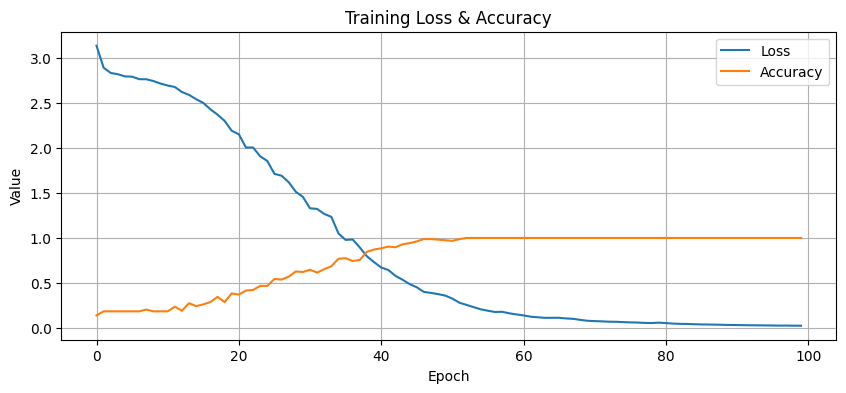


Generated Text:

to be, or not to be, that is the quen whher 'ioe oerl to sloee  rbl     on  ar  ffettarram fsootneeeeeo oo  toruaums  aauu ths  aa arrrtoo  ae  oor aoo   oe  tootaaer  ffgg en      ions  ne soo  oo taamsssstunne eo  oo tarerisst  e ain 
Total sequences: 156


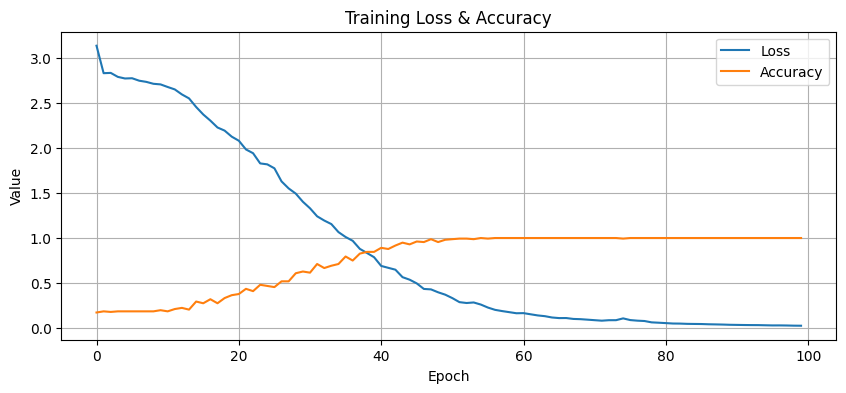


Generated Text:

to be, or not to be, that is the quen   teer 'mer  sbooonnneee rrrms   aa  s  aaaisssseeerooooouuueeee r   i    aaseeeerenseeee  eeeeeeeer   r       sbebeeeerrr     tteeeeeeeeerrr       saaaaaarrooooooouuuuee h  naeeeerrrr     aaaaabuue


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import LSTM, Dense
import re

# Load and clean Shakespeare sample text
text = """
To be, or not to be, that is the question:
Whether 'tis nobler in the mind to suffer
The slings and arrows of outrageous fortune,
Or to take arms against a sea of troubles
And by opposing end them."""


text = text.lower()
text = re.sub(r'[^a-zA-Z .,!?\'\"]+', '', text)

# Create character to integer mapping
chars = sorted(list(set(text)))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for c, i in char_to_int.items()}

# Create sequences
seq_length = 40
step = 1
sequences = []
next_chars = []
for i in range(0, len(text) - seq_length, step):
    sequences.append(text[i:i+seq_length])
    next_chars.append(text[i + seq_length])
print("Total sequences:", len(sequences))

# Encode sequences
X = np.zeros((len(sequences), seq_length, len(chars)), dtype=bool)
y = np.zeros((len(sequences), len(chars)), dtype=bool)
for i, seq in enumerate(sequences):
    for t, char in enumerate(seq):
        X[i, t, char_to_int[char]] = 1
    y[i, char_to_int[next_chars[i]]] = 1

# Build LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(seq_length, len(chars))))
model.add(Dense(len(chars), activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(X, y, batch_size=8, epochs=100, verbose=0)

# Plot loss/accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Training Loss & Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Text Generation Function
def generate_text(seed_text, length=200):
    generated = seed_text.lower()
    for _ in range(length):
        x_pred = np.zeros((1, seq_length, len(chars)), dtype=bool)
        for t, char in enumerate(seed_text):
            if char in char_to_int:
                x_pred[0, t, char_to_int[char]] = 1
        pred = model.predict(x_pred, verbose=0)[0]
        next_index = np.argmax(pred)
        next_char = int_to_char[next_index]
        generated += next_char
        seed_text = seed_text[1:] + next_char
    return generated

# Example text generation
seed_text = "to be, or not to be, that is the que"
print("\nGenerated Text:\n")
print(generate_text(seed_text))
chars = sorted(list(set(text)))
char_to_int = {c: i for i, c in enumerate(chars)}
int_to_char = {i: c for c, i in char_to_int.items()}

# Create sequences
seq_length = 40
step = 1
sequences = []
next_chars = []
for i in range(0, len(text) - seq_length, step):
    sequences.append(text[i:i+seq_length])
    next_chars.append(text[i + seq_length])
print("Total sequences:", len(sequences))

# Encode sequences
X = np.zeros((len(sequences), seq_length, len(chars)), dtype=bool)
y = np.zeros((len(sequences), len(chars)), dtype=bool)
for i, seq in enumerate(sequences):
    for t, char in enumerate(seq):
        X[i, t, char_to_int[char]] = 1
    y[i, char_to_int[next_chars[i]]] = 1

# Build LSTM model
model = Sequential()
model.add(LSTM(128, input_shape=(seq_length, len(chars))))
model.add(Dense(len(chars), activation='softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train
history = model.fit(X, y, batch_size=8, epochs=100, verbose=0)

# Plot loss/accuracy
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['accuracy'], label='Accuracy')
plt.title('Training Loss & Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Text Generation Function
def generate_text(seed_text, length=200):
    generated = seed_text.lower()
    for _ in range(length):
        x_pred = np.zeros((1, seq_length, len(chars)), dtype=bool)
        for t, char in enumerate(seed_text):
            if char in char_to_int:
                x_pred[0, t, char_to_int[char]] = 1
        pred = model.predict(x_pred, verbose=0)[0]
        next_index = np.argmax(pred)
        next_char = int_to_char[next_index]
        generated += next_char
        seed_text = seed_text[1:] + next_char
    return generated

# Example text generation
seed_text = "to be, or not to be, that is the que"
print("\nGenerated Text:\n")
print(generate_text(seed_text))

Sample Data:
   label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
Epoch 1/5


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


70/70 ━━━━━━━━━━━━━━━━━━━━ 25s 276ms/step - accuracy: 0.8561 - loss: 0.3608 - val_accuracy: 0.9821 - val_loss: 0.0591
Epoch 2/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 22s 289ms/step - accuracy: 0.9855 - loss: 0.0516 - val_accuracy: 0.9874 - val_loss: 0.0423
Epoch 3/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 19s 271ms/step - accuracy: 0.9922 - loss: 0.0325 - val_accuracy: 0.9919 - val_loss: 0.0343
Epoch 4/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 20s 280ms/step - accuracy: 0.9961 - loss: 0.0168 - val_accuracy: 0.9910 - val_loss: 0.0345
Epoch 5/5
70/70 ━━━━━━━━━━━━━━━━━━━━ 21s 285ms/step - accuracy: 0.9965 - loss: 0.0137 - val_accuracy: 0.9910 - val_loss: 0.0380


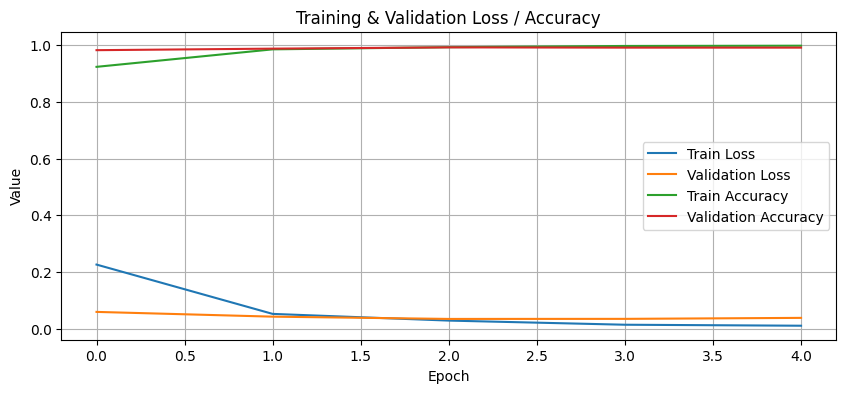

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step

Classification Report:

              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.99      0.95      0.97       149

    accuracy                           0.99      1115
   macro avg       0.99      0.97      0.98      1115
weighted avg       0.99      0.99      0.99      1115



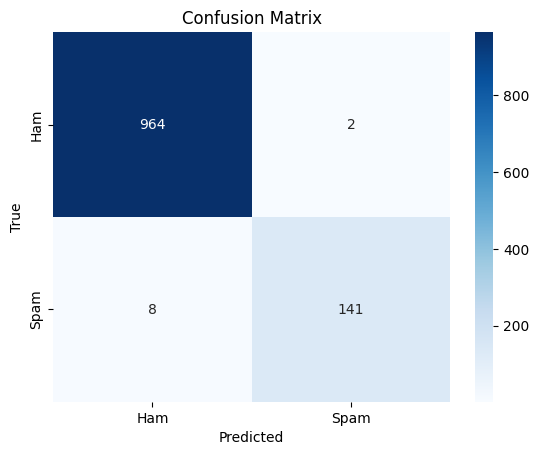

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, SpatialDropout1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

# Load Dataset
url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"
df = pd.read_csv(url, sep='\t', names=["label", "message"])
print("Sample Data:\n", df.head())

# Encode Labels
df['label'] = df['label'].map({'ham': 0, 'spam': 1})

# Text Tokenization and Padding
max_words = 5000
max_len = 100
tokenizer = Tokenizer(num_words=max_words, lower=True)
tokenizer.fit_on_texts(df['message'].values)
X = tokenizer.texts_to_sequences(df['message'].values)
X = pad_sequences(X, maxlen=max_len)
y = df['label'].values

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build LSTM Model
model = Sequential()
model.add(Embedding(max_words, 128, input_length=max_len))
model.add(SpatialDropout1D(0.2))
model.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train the Model
history = model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test), verbose=1)

# Plot Accuracy and Loss
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training & Validation Loss / Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()

# Evaluate the Model
y_pred = (model.predict(X_test) > 0.5).astype("int32")

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()